In [2]:
from geotab_processor import GeotabProcessor

processor = GeotabProcessor('config.yml')

Trip date: 2026-03-06


In [2]:
# Process and preview vars (motor status report)
vars_df = processor.process_vars()
vars_df.head(15)

vars: 458 rows


,datetime,Voltage,Current,Power,SoC,Procedencia
0,2026-03-06 08:26:49.258,373.000000,1.000000,373.0,76.585000,AA
1,2026-03-06 08:32:26.863,372.894628,-58.515190,-21820.0,76.500769,AA
2,2026-03-06 08:32:36.895,372.789256,22.951305,8556.0,76.416538,AA
3,2026-03-06 08:33:24.125,372.683884,30.859934,11501.0,76.332308,AA
4,2026-03-06 08:33:30.152,372.578512,13.030811,4855.0,76.248077,AA
5,2026-03-06 08:33:32.168,372.473140,-93.131548,-34689.0,76.163846,AA
6,2026-03-06 08:33:35.168,372.367769,26.616160,9911.0,76.079615,AA
7,2026-03-06 08:33:58.270,372.262397,-48.417461,-18024.0,75.995385,AA
8,2026-03-06 08:34:21.355,372.157025,48.218894,17945.0,75.911154,AA
9,2026-03-06 08:34:25.379,372.051653,-115.793062,-43081.0,75.826923,AA


In [3]:
# Process and preview GPS (data log)
gps_df = processor.process_gps()
gps_df.head(15)

gps: 1393 rows


,datetime,latitude,longitude
0,2026-03-06 08:26:44.394,9.93678,-84.04376
1,2026-03-06 08:26:44.414,9.93678,-84.04376
2,2026-03-06 08:26:45.000,9.93673,-84.04379
3,2026-03-06 08:27:30.162,9.93673,-84.04379
4,2026-03-06 08:27:39.000,9.93673,-84.04379
5,2026-03-06 08:27:41.000,9.93671,-84.04378
6,2026-03-06 08:27:42.000,9.93670,-84.04377
7,2026-03-06 08:27:50.000,9.93656,-84.04366
8,2026-03-06 08:27:53.000,9.93647,-84.04366
9,2026-03-06 08:27:58.000,9.93626,-84.04367


In [4]:
# Merge vars into GPS → route_vars
route_vars_df = processor.merge_route_vars()
route_vars_df.head(15)

route_vars: 1393 rows


,datetime,latitude,longitude,Voltage,Current,Power,SoC,Procedencia
0,2026-03-06 08:26:44.394,9.93678,-84.04376,373.000000,1.000000,373.000000,76.585000,AA
1,2026-03-06 08:26:44.414,9.93678,-84.04376,373.000000,1.000000,373.000000,76.585000,AA
2,2026-03-06 08:26:45.000,9.93673,-84.04379,373.000000,1.000000,373.000000,76.585000,AA
3,2026-03-06 08:27:30.162,9.93673,-84.04379,372.998327,0.055314,20.730159,76.583663,AA
4,2026-03-06 08:27:39.000,9.93673,-84.04379,372.996655,-0.889371,-331.539683,76.582326,AA
5,2026-03-06 08:27:41.000,9.93671,-84.04378,372.994982,-1.834057,-683.809524,76.580989,AA
6,2026-03-06 08:27:42.000,9.93670,-84.04377,372.993310,-2.778742,-1036.079365,76.579652,AA
7,2026-03-06 08:27:50.000,9.93656,-84.04366,372.991637,-3.723428,-1388.349206,76.578315,AA
8,2026-03-06 08:27:53.000,9.93647,-84.04366,372.989965,-4.668113,-1740.619048,76.576978,AA
9,2026-03-06 08:27:58.000,9.93626,-84.04367,372.988292,-5.612799,-2092.888889,76.575641,AA


In [5]:
# Save all outputs to CSV
processor.save()

Saved vars → processed_data\2026-03-06\vars.csv  (458 rows)
Saved gps  → processed_data\2026-03-06\gps.csv  (1393 rows)
Saved route_vars → processed_data\2026-03-06\route_vars.csv  (1393 rows)


In [6]:
# Densify route_vars (interpolate GPS points to fill gaps)
route_vars_df = processor.densify_gps()
print(f"Shape: {route_vars_df.shape}")

# Save densified route_vars to CSV
processor.save()

route_vars_df.head(15)

densify: 1393 → 19823 points (max gap 5m)
Shape: (19823, 8)
Saved vars → processed_data\2026-03-06\vars.csv  (458 rows)
Saved gps  → processed_data\2026-03-06\gps.csv  (1393 rows)
Saved route_vars → processed_data\2026-03-06\route_vars.csv  (19823 rows)


,datetime,latitude,longitude,Voltage,Current,Power,SoC,Procedencia
0,2026-03-06 08:26:44.394000000,9.936780,-84.043760,373.000000,1.000000,373.000000,76.585000,AA
1,2026-03-06 08:26:44.414000000,9.936780,-84.043760,373.000000,1.000000,373.000000,76.585000,AA
2,2026-03-06 08:26:44.707000064,9.936755,-84.043775,373.000000,1.000000,373.000000,76.585000,AA
3,2026-03-06 08:26:45.000000000,9.936730,-84.043790,373.000000,1.000000,373.000000,76.585000,AA
4,2026-03-06 08:27:30.162000000,9.936730,-84.043790,372.998327,0.055314,20.730159,76.583663,AA
5,2026-03-06 08:27:39.000000000,9.936730,-84.043790,372.996655,-0.889371,-331.539683,76.582326,AA
6,2026-03-06 08:27:41.000000000,9.936710,-84.043780,372.994982,-1.834057,-683.809524,76.580989,AA
7,2026-03-06 08:27:42.000000000,9.936700,-84.043770,372.993310,-2.778742,-1036.079365,76.579652,AA
8,2026-03-06 08:27:44.000000000,9.936665,-84.043742,372.992892,-3.014914,-1124.146825,76.579318,AA
9,2026-03-06 08:27:46.000000000,9.936630,-84.043715,372.992473,-3.251085,-1212.214286,76.578984,AA


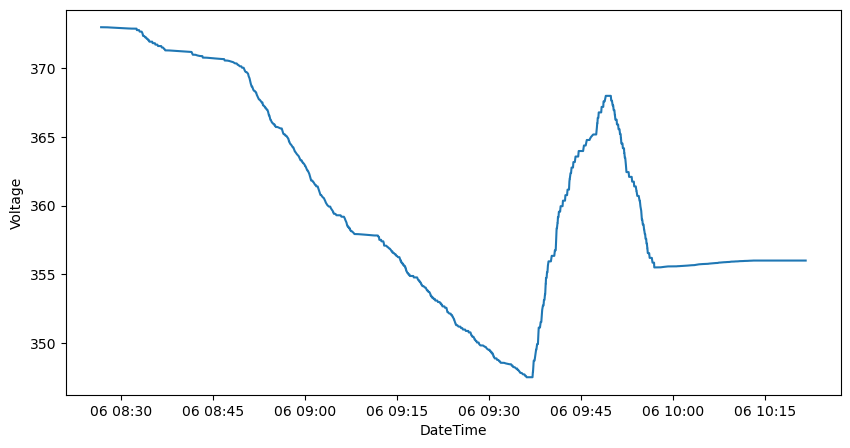

In [7]:
#plot SoC
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 5))
plt.plot(route_vars_df['datetime'], route_vars_df['Voltage'])
plt.xlabel('DateTime')
plt.ylabel('Voltage')
plt.show()

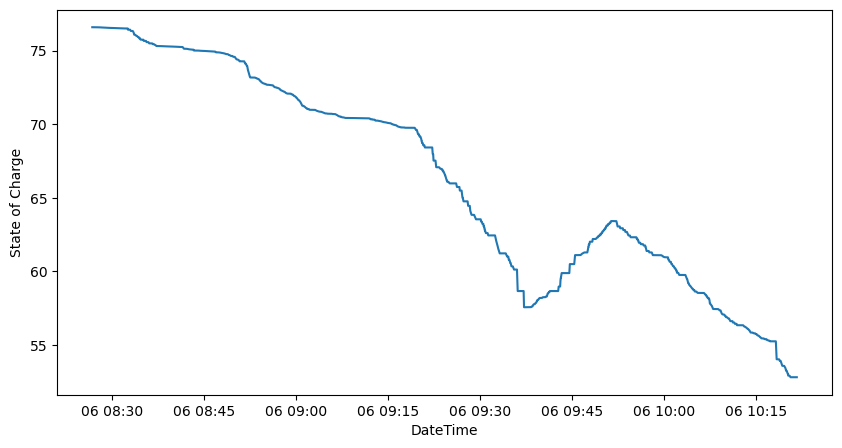

In [8]:
#plot SoC
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 5))
plt.plot(route_vars_df['datetime'], route_vars_df['SoC'])
plt.xlabel('DateTime')
plt.ylabel('State of Charge')
plt.show()

In [9]:
from GetFeatures import GetFeatures

feat = GetFeatures('config.yml', trip_date=processor.trip_date)
features_df = feat.run()
features_df.head(15)

Loaded 19823 points from processed_data\2026-03-06\route_vars.csv
  Total distance: 95.53 km
  Segments: 930 (target 100m)
  Weather fetched (2 location(s))
  Road features extracted
  Elevation fetched
  Slope computed
  Aggregated into 930 segments
Saved features → processed_data\2026-03-06\features.csv


,segment_id,Hour,Trip_distance,Delta_d,Hum,OAT[DegC]_API,precipMM,Slope,primary,residential,secondary,crossing,tertiary,give_way,Voltage,Current,Power,SoC
0,0,8,100.363613,100.363613,67.0,23.0,0.0,0.570863,0,0,0,0,0,0,372.991518,-3.790905,-1413.511338,76.578220
1,1,8,200.715113,100.351500,67.0,23.0,0.0,0.000000,0,0,0,0,0,0,372.979245,-10.722689,-3998.348485,76.568409
2,2,8,300.970235,100.255123,67.0,23.0,0.0,0.000000,0,1,0,0,0,0,372.970350,-15.746698,-5871.783550,76.561299
3,3,8,404.513920,103.543684,67.0,23.0,0.0,-6.610695,0,1,0,0,0,0,372.956668,-23.474354,-8753.398295,76.550362
4,4,8,506.361603,101.847684,67.0,23.0,0.0,0.000000,0,1,0,0,0,0,372.944440,-30.380737,-11328.763636,76.540587
5,5,8,608.189089,101.827485,67.0,23.0,0.0,0.000000,0,0,0,0,0,0,372.940955,-32.349328,-12062.844315,76.537801
6,6,8,711.783452,103.594363,67.0,23.0,0.0,0.000000,0,0,0,0,0,0,372.933897,-36.335616,-13549.316770,76.532160
7,7,8,815.083452,103.300000,67.0,23.0,0.0,0.000000,0,0,0,0,0,0,372.927058,-40.198616,-14989.815648,76.526692
8,8,8,916.750793,101.667341,67.0,23.0,0.0,0.000000,0,0,0,0,0,0,372.923047,-42.463668,-15834.445324,76.523487
9,9,8,1018.197005,101.446212,67.0,23.0,0.0,-2.821665,0,0,0,0,0,0,372.919534,-44.448314,-16574.512531,76.520678


In [5]:
from geotab_processor import GeotabProcessor

processor = GeotabProcessor('config.yml')
from SelectRoutes import SelectRoutes

router = SelectRoutes('config.yml', trip_date=processor.trip_date)

# Define origin, destination, and optional waypoints (lat, lon)
origin = (9.938431618596065, -84.04242771006302)
destination = (9.923002036510496, -84.71348341082084)
waypoints = [
    (9.946408312880324, -84.1075270242855),
    (9.998852155871559, -84.20965794599373),
    (9.992262390787275, -84.32110029105247),
    (9.986162599612205, -84.33666694801252),
    (9.960107878275323, -84.35899648875584),
    (9.94379395064879, -84.37234399566964),
    (9.942631291491299, -84.3989518633456),
    (9.906426084502195, -84.52176653130655),
    (9.890576370313543, -84.56242082436405)

]

route_df, travel = router.run(origin, destination, waypoints)
print(travel)
route_df.head(15)

Trip date: 2026-03-06
Requesting route from OSRM...
Route found: 1849 geometry points, 89.27 km, 105.89 min
Interpolated 17866 GPS points (every 5 m)
Saved route → processed_data\2026-03-06\route_coords.csv (17866 points)
Saved map  → processed_data\2026-03-06\route_map.html
{'duration_seconds': 6353.1, 'duration_minutes': 105.89, 'distance_km': 89.27, 'origin': (9.938431618596065, -84.04242771006302), 'destination': (9.923002036510496, -84.71348341082084)}


,latitude,longitude
0,9.939200,-84.041710
1,9.939200,-84.041710
2,9.939229,-84.041745
3,9.939260,-84.041778
4,9.939296,-84.041805
5,9.939331,-84.041833
6,9.939370,-84.041856
7,9.939410,-84.041877
8,9.939450,-84.041898
9,9.939490,-84.041919
